 8. In this exercise, we will generate simulated data, and will then use
 this data to perform forward and backward stepwise selection.

### (a)
Create a random number generator and use its `normal()` method to generate:

- a predictor \(X\) of length \(n = 100\), and  
- a noise vector \(\varepsilon\) of length \(n = 100\).

In [1]:
import numpy as np

# (a) 建立 random number generator
rng = np.random.default_rng(seed=0)   # 固定 seed 方便重現結果

n = 100  # 樣本數

# 用 normal() 產生 X 與 noise
X = rng.normal(loc=0.0, scale=1.0, size=n)      # predictor X
eps = rng.normal(loc=0.0, scale=1.0, size=n)    # noise term ε

print("X 前 5 個值：", X[:5])
print("eps 前 5 個值：", eps[:5])
print("長度檢查：", len(X), len(eps))


X 前 5 個值： [ 0.12573022 -0.13210486  0.64042265  0.10490012 -0.53566937]
eps 前 5 個值： [ 0.50268285  0.98971303 -0.16429459 -1.07436486  0.87304215]
長度檢查： 100 100


### (b)

Generate a response vector $Y$ of length $n = 100$ according to

$$
Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \varepsilon,
$$

where $\beta_0,\beta_1,\beta_2,\beta_3$ are constants of your choice.


In [4]:
# ========== (b) 生成模擬資料：Y = β0 + β1 X + β2 X^2 + β3 X^3 + ε ==========

import numpy as np
import pandas as pd


# 自己選一組 β0, β1, β2, β3
beta0 = 1.0
beta1 = 2.0
beta2 = 3.0
beta3 = 4.0

# 依照題目公式生成 Y
Y = beta0 + beta1 * X + beta2 * X**2 + beta3 * X**3 + eps

print("Y 長度:", len(Y))
print("Y 前 5 個:", Y[:5])

df = pd.DataFrame({"Y": Y})
for p in range(1, 11):
    df[f"X{p}"] = X**p

# 之後會常用到這個 list
candidate_cols = [f"X{i}" for i in range(1, 11)]

print("\n(df 前 5 列)")
print(df.head())


Y 長度: 100
Y 前 5 個: [1.80951778 1.76863658 4.39762901 0.17306478 1.04770496]

(df 前 5 列)
          Y        X1        X2        X3        X4        X5        X6  \
0  1.809518  0.125730  0.015808  0.001988  0.000250  0.000031  0.000004   
1  1.768637 -0.132105  0.017452 -0.002305  0.000305 -0.000040  0.000005   
2  4.397629  0.640423  0.410141  0.262664  0.168216  0.107729  0.068992   
3  0.173065  0.104900  0.011004  0.001154  0.000121  0.000013  0.000001   
4  1.047705 -0.535669  0.286942 -0.153706  0.082336 -0.044105  0.023625   

             X7            X8            X9           X10  
0  4.966812e-07  6.244784e-08  7.851581e-09  9.871810e-10  
1 -7.021528e-07  9.275780e-08 -1.225376e-08  1.618781e-09  
2  4.418418e-02  2.829655e-02  1.812175e-02  1.160558e-02  
3  1.397757e-07  1.466249e-08  1.538097e-09  1.613466e-10  
4 -1.265545e-02  6.779139e-03 -3.631377e-03  1.945217e-03  


### (c)
Use forward stepwise selection to select a model containing the predictors

    X, X^2, ..., X^10.

Determine the selected model according to Mallows’ Cp, and report the coefficient estimates.

In [5]:
# ========== (c) Forward Stepwise Selection（用 Cp） ==========

import statsmodels.api as sm
import math

# 先寫幾個小工具：估 sigma^2、算 Cp、前向逐步

def compute_sigma2_hat(df, y_col, x_cols):
    """
    用全部變數的 OLS 來估計 sigma^2:
    sigma^2_hat = RSS / (n - p), p = 參數個數(含截距)
    """
    n = df.shape[0]
    X_full = sm.add_constant(df[x_cols])
    y = df[y_col]
    full_model = sm.OLS(y, X_full).fit()
    p = len(full_model.params)
    sigma2_hat = full_model.ssr / (n - p)
    return sigma2_hat

def fit_subset_Cp(df, y_col, predictors, sigma2_hat):
    """
    給定一組 predictors（例如 ['X1','X2']），回傳：
    - model: OLS 拟合結果
    - Cp: 該 subset 的 Mallows Cp
    Cp = RSS / sigma2_hat - (n - 2p)
    """
    n = df.shape[0]
    X = sm.add_constant(df[predictors])
    y = df[y_col]
    model = sm.OLS(y, X).fit()
    RSS = model.ssr
    p = len(model.params)   # 含截距
    Cp = RSS / sigma2_hat - (n - 2 * p)
    return model, Cp

def forward_stepwise(df, y_col, candidate_cols, sigma2_hat):
    """
    前向逐步選取：
    - 從空集合開始
    - 每次加入一個變數，使 Cp 最小
    - 回傳：Cp 最小的那個 subset 與 model
    """
    remaining = list(candidate_cols)
    selected = []
    history = []   # 存 (selected_list, model, Cp)

    while remaining:
        best_cp = math.inf
        best_model = None
        best_var = None

        for var in remaining:
            trial_predictors = selected + [var]
            model, cp = fit_subset_Cp(df, y_col, trial_predictors, sigma2_hat)
            if cp < best_cp:
                best_cp = cp
                best_model = model
                best_var = var

        # 把這一步最好的變數加入
        selected.append(best_var)
        remaining.remove(best_var)
        history.append((selected.copy(), best_model, best_cp))

    # 在整條 path 裡，找 Cp 最小的 subset
    best = min(history, key=lambda t: t[2])
    best_predictors, best_model, best_cp = best
    return best_predictors, best_model, best_cp, history

# ---- 實際執行 (c) ----

# 用全部 X1...X10 的模型估 sigma^2
sigma2_hat = compute_sigma2_hat(df, "Y", candidate_cols)

# 前向逐步選取
fwd_best_predictors, fwd_best_model, fwd_best_cp, fwd_history = forward_stepwise(
    df, "Y", candidate_cols, sigma2_hat
)

print("\n===== (c) Forward Stepwise (用 Cp) =====")
print("選到的變數：", fwd_best_predictors)
print("對應 Cp：", fwd_best_cp)
print("估計係數：")
print(fwd_best_model.params)



===== (c) Forward Stepwise (用 Cp) =====
選到的變數： ['X3', 'X2', 'X1']
對應 Cp： 4.662435960451205
估計係數：
const    0.951234
X3       3.889803
X2       3.000471
X1       2.304259
dtype: float64


### (d)
Repeat (c) using backward stepwise selection. Compare the result with (c).

In [6]:
# ========== (d) Backward Stepwise Selection（用 Cp） ==========

def backward_stepwise(df, y_col, candidate_cols, sigma2_hat):
    """
    後向逐步選取：
    - 從所有變數開始
    - 每一步刪掉一個變數，使 Cp 最小
    - 最後在整條 path 中挑 Cp 最小者
    """
    selected = list(candidate_cols)
    history = []

    while selected:
        # 先記錄目前這組 selected 的 Cp
        model, cp = fit_subset_Cp(df, y_col, selected, sigma2_hat)
        history.append((selected.copy(), model, cp))

        if len(selected) == 1:
            break

        best_cp = math.inf
        best_model = None
        best_var_to_drop = None

        # 試著一次丟掉一個變數
        for var in selected:
            trial_predictors = [v for v in selected if v != var]
            model_sub, cp_sub = fit_subset_Cp(df, y_col, trial_predictors, sigma2_hat)
            if cp_sub < best_cp:
                best_cp = cp_sub
                best_model = model_sub
                best_var_to_drop = var

        # 真正把該變數 drop 掉
        selected.remove(best_var_to_drop)

    # 看整條 path 裡 Cp 最小的是誰
    best = min(history, key=lambda t: t[2])
    best_predictors, best_model, best_cp = best
    return best_predictors, best_model, best_cp, history

# ---- 實際執行 (d) ----

bwd_best_predictors, bwd_best_model, bwd_best_cp, bwd_history = backward_stepwise(
    df, "Y", candidate_cols, sigma2_hat
)

print("\n===== (d) Backward Stepwise (用 Cp) =====")
print("選到的變數：", bwd_best_predictors)
print("對應 Cp：", bwd_best_cp)
print("估計係數：")
print(bwd_best_model.params)

# 你可以自己比對 fwd_best_predictors 跟 bwd_best_predictors 是否一樣



===== (d) Backward Stepwise (用 Cp) =====
選到的變數： ['X1', 'X2', 'X3']
對應 Cp： 4.662435960451205
估計係數：
const    0.951234
X1       2.304259
X2       3.000471
X3       3.889803
dtype: float64


### (e)
Fit a lasso model to the simulated data using predictors X, X^2, ..., X^10.
Use cross-validation to choose the optimal value of λ. Plot the cross-validation error versus λ, and report the coefficient estimates.


===== (e) LassoCV 結果 =====
選到的最佳 lambda (alpha)： 0.012107222053917033
各變數係數（在標準化空間下）：
X1: 2.3729
X2: 3.4171
X3: 9.6756
X4: 0.0000
X5: 0.0000
X6: 0.0000
X7: 0.0000
X8: -0.0000
X9: 0.2555
X10: -0.0000
截距 (intercept)： 4.885509999194703


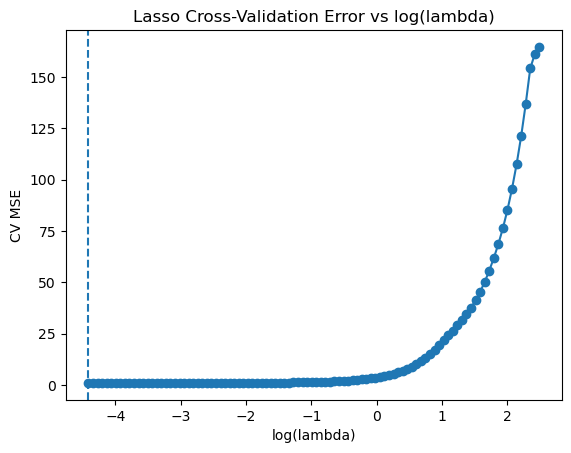

In [7]:
# ========== (e) Lasso + Cross-Validation ==========

from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# 取出 X 矩陣 & y
X_mat = df[candidate_cols].values   # X1...X10
y_vec = df["Y"].values

# 用 pipeline：先標準化，再做 LassoCV
lasso_pipe = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    LassoCV(cv=10, random_state=0)
)

lasso_pipe.fit(X_mat, y_vec)

# 從 pipeline 把 LassoCV 模型取出來
lasso_model = lasso_pipe.named_steps["lassocv"]

print("\n===== (e) LassoCV 結果 =====")
print("選到的最佳 lambda (alpha)：", lasso_model.alpha_)
print("各變數係數（在標準化空間下）：")
for name, coef in zip(candidate_cols, lasso_model.coef_):
    print(f"{name}: {coef:.4f}")
print("截距 (intercept)：", lasso_model.intercept_)

# 畫 CV 誤差 vs log(lambda)
mean_mse = lasso_model.mse_path_.mean(axis=1)  # 對 folds 取平均
alphas = lasso_model.alphas_

plt.figure()
plt.plot(np.log(alphas), mean_mse, marker="o")
plt.axvline(np.log(lasso_model.alpha_), linestyle="--")
plt.xlabel("log(lambda)")
plt.ylabel("CV MSE")
plt.title("Lasso Cross-Validation Error vs log(lambda)")
plt.show()


### (f)
Generate a new response vector according to

    Y = β0 + β7 X^7 + ε,

and again perform forward stepwise selection and lasso using predictors X, X^2, ..., X^10. Discuss the results.


===== (f) Forward Stepwise for Y = β0 + β7 X^7 + ε =====
選到的變數： ['X7', 'X10', 'X5', 'X2']
對應 Cp： 1.1225057425215823
估計係數：
const    1.000689
X7       7.043930
X10      0.001584
X5      -0.137242
X2      -0.236940
dtype: float64

LassoCV (Y = β0 + β7 X^7 + ε) 結果：
最佳 lambda (alpha)： 0.3447228514362025
各變數係數（在標準化空間下）：
X1: -2.1317
X2: 0.0000
X3: -0.0000
X4: 0.0000
X5: 44.9089
X6: 0.0000
X7: 244.6105
X8: 0.0000
X9: 57.3946
X10: 0.0000
截距 (intercept)： -4.927059343787539


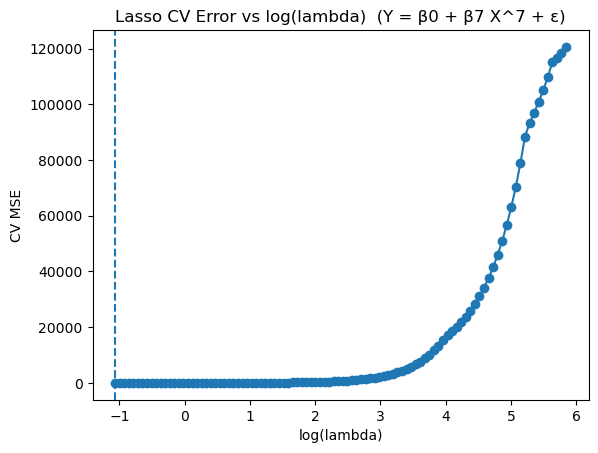

In [8]:
# ========== (f) 新模型：Y = β0 + β7 X^7 + ε ==========

# 重新生成一個新的 Y2
beta0_f = 1.0
beta7_f = 7.0
eps2 = rng.normal(loc=0.0, scale=1.0, size=n)

Y2 = beta0_f + beta7_f * X**7 + eps2

# 準備新的 DataFrame df2（X^1...X^10 一樣）
df2 = pd.DataFrame({"Y": Y2})
for p in range(1, 11):
    df2[f"X{p}"] = X**p

# 用新的資料重新估 sigma^2
sigma2_hat_2 = compute_sigma2_hat(df2, "Y", candidate_cols)

# (f) Forward stepwise 在新模型上
fwd2_best_predictors, fwd2_best_model, fwd2_best_cp, fwd2_history = forward_stepwise(
    df2, "Y", candidate_cols, sigma2_hat_2
)

print("\n===== (f) Forward Stepwise for Y = β0 + β7 X^7 + ε =====")
print("選到的變數：", fwd2_best_predictors)
print("對應 Cp：", fwd2_best_cp)
print("估計係數：")
print(fwd2_best_model.params)

# (f) Lasso 在新模型上
X2_mat = df2[candidate_cols].values
y2_vec = df2["Y"].values

lasso2_pipe = make_pipeline(
    StandardScaler(with_mean=True, with_std=True),
    LassoCV(cv=10, random_state=0)
)
lasso2_pipe.fit(X2_mat, y2_vec)
lasso2_model = lasso2_pipe.named_steps["lassocv"]

print("\nLassoCV (Y = β0 + β7 X^7 + ε) 結果：")
print("最佳 lambda (alpha)：", lasso2_model.alpha_)
print("各變數係數（在標準化空間下）：")
for name, coef in zip(candidate_cols, lasso2_model.coef_):
    print(f"{name}: {coef:.4f}")
print("截距 (intercept)：", lasso2_model.intercept_)

# 也可以再畫一次新的 CV curve（選擇性）
mean_mse2 = lasso2_model.mse_path_.mean(axis=1)
alphas2 = lasso2_model.alphas_

plt.figure()
plt.plot(np.log(alphas2), mean_mse2, marker="o")
plt.axvline(np.log(lasso2_model.alpha_), linestyle="--")
plt.xlabel("log(lambda)")
plt.ylabel("CV MSE")
plt.title("Lasso CV Error vs log(lambda)  (Y = β0 + β7 X^7 + ε)")
plt.show()
